# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

### Business framing:  

### Do the following:
Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows

### In Your Response:
1. What stands out in the initial preview? Any columns or rows that seem unusual?

In [20]:
# Add code here 🔧
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/hotels.csv"
df = pd.read_csv(url)

# Display first few rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### ✍️ Your Response: 🔧
1. Based on this inital preview there are several things that stand out. For example, we can see that there are some very large values in the lead_time feature such as 737 days. Which means some customers book more than 2 years in advance which is unusually high. There are also missing values in agent and company columns, meaning the data is incomplete. The adr has 0.0 in some rows which is unusual and could indicate possible data entry issues. Lastly, we can also see that resort hotel are in all 5 rows which may mean the data is in order by type and not shuffled.

## 2. Select and Prepare Features

### Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

### Do the following:
- Choose 3–5 numeric features related to customer behavior
- Drop missing values if needed
- Standardize using `StandardScaler`

### In Your Response:
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?


In [21]:
# Add code here 🔧
from sklearn.preprocessing import StandardScaler

# select features
features = ['lead_time', 'stays_in_week_nights','stays_in_weekend_nights']

# drop missing values
df_clean = df[features].dropna()

# standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

print(X_scaled[:5])

[[ 2.22705112 -1.31023993 -0.92889042]
 [ 5.9233847  -1.31023993 -0.92889042]
 [-0.90781407 -0.78620716 -0.92889042]
 [-0.85166723 -0.78620716 -0.92889042]
 [-0.84230942 -0.2621744  -0.92889042]]


### ✍️ Your Response: 🔧
1. I selected lead_time, stays_in_week_nights, and stays_in_weekend_nights because they seem to directly represent guest booking behavior. Lead time shows how far ahead a customer books while helps us identify early planners. The weekend and weekday variables shows us how long guests stay and if there trips are more business focuesd or not.

2. Based on these I have selected, I expect to find segments like short stay vs long stay guests, last minute customers vs early booking, and others like weekday vs weekend travelers. These kinds of clusters can help managment know what kinds of patterns they currently have.


## 3. Apply K-Means Clustering

### Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

### Do the following:
- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign to each guest
- Visualize using a scatterplot of 2 features

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

### In Your Response:
1. What `k` value did you choose, and how did you decide?
2. What types of customers seem to show up in the clusters?



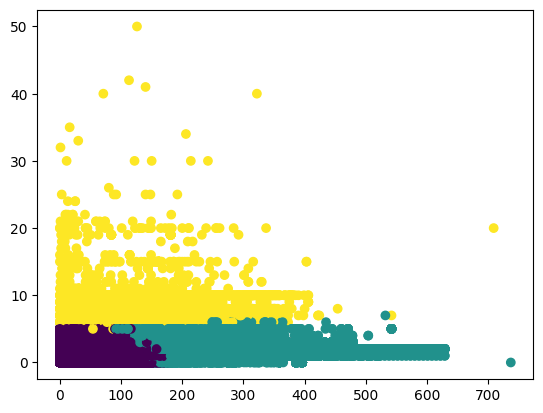

In [22]:
# Add code here 🔧
from sklearn.cluster import KMeans

# choose k and fit
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# assign clusters
df_clean["cluster"] = clusters

# scatterplot (2 features)
plt.scatter(df_clean["lead_time"], df_clean["stays_in_week_nights"], c=clusters)
plt.show()

### ✍️ Your Response: 🔧
1. I picked k=3 because it makes a smaller number of clear customer groups. Since the goal was to help target different types of guests, having 3 keeps the segments easy and simple. Having to many clusters can make results hard to understand.

2. In the clusters we seem to have 3 types of customers. The largest seems to be short stay guets who book closer to their arrival date and stay an average number of nights. The second group is of early planners who book far in adance and do not stay to long. The smallest is long stay guests which much higher weekend and weekday stays overall.


## 4. Apply Gaussian Mixture Model (GMM)

### Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

### Do the following:
- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the GMM model so that you may compare it to the KMeans scatterplot

### In Your Response:
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?


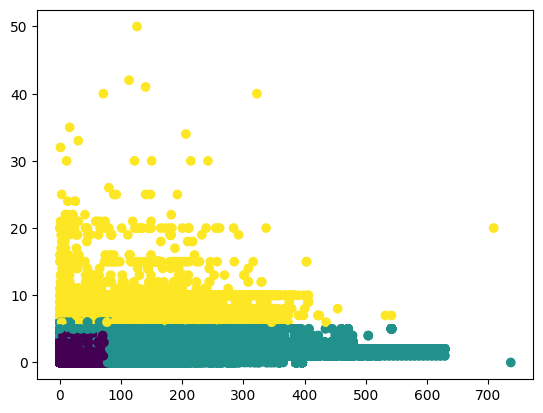

In [23]:
# Add your code here
from sklearn.mixture import GaussianMixture

# fit GMM
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_scaled)

# soft clustering
probs = gmm.predict_proba(X_scaled)

labels = np.argmax(probs, axis=1)

# scatterplot
plt.scatter(df_clean["lead_time"], df_clean["stays_in_week_nights"], c=labels)
plt.show()

### ✍️ Your Response: 🔧
1. It seems that these results for the GMM were very similar to the KMeans result. The 3 clusters follow the same pattern overall. However, unlike KMeans, this one provides probabilites for eac hguest belonging to each cluter. This means that the GMM captures overlap between customer types better than the other model.

2. GMM helps answer questions about customers who did not fit perfectly in a category. For example, it can show guests who behave partly like long stay traverls and partly like short stay which allows a business to make more flexible strategies rather than treating customers as a strict group.


## 5. Evaluate Your Models

### Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

### Do the following:
- Calculate the following **for each** of the models:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index

  **NOTE:** This step may take up to 5 minutes.  It is a lot of computation time.  Please be patient.  Or you can limit the scores to using a random sample of 10K rows.

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

### In Your Response:
1. Which model performed better on the metrics?
2. Would you recommend KMeans or GMM for a business analyst? Why?


In [24]:
# Add code here 🔧
# sample 10k rows for speed
sample_idx = np.random.choice(len(X_scaled), 10000, replace=False)
X_sample = X_scaled[sample_idx]


In [26]:
# KMEANS METRICS
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np

kmeans_sample = KMeans(n_clusters=3, random_state=42)
k_labels = kmeans_sample.fit_predict(X_sample)

k_wcss = kmeans_sample.inertia_
k_sil = silhouette_score(X_sample, k_labels)
k_db = davies_bouldin_score(X_sample, k_labels)

In [27]:
# GMM METRICS
gmm_sample = GaussianMixture(n_components=3, random_state=42)
gmm_sample.fit(X_sample)
g_labels = gmm_sample.predict(X_sample)

g_wcss = np.sum((X_sample - gmm_sample.means_[g_labels])**2)
g_sil = silhouette_score(X_sample, g_labels)
g_db = davies_bouldin_score(X_sample, g_labels)

In [28]:
print("KMeans:", k_wcss, k_sil, k_db)
print("GMM:", g_wcss, g_sil, g_db)

KMeans: 14895.493646333733 0.3816241357557667 1.0217862205022412
GMM: 17337.431779269333 0.2792134127111769 1.3070264357221164


### ✍️ Your Response: 🔧
1. KMeans performed better on the metrics. It is clear that it has a lower WCSS (14895 vs 17337), a higher Silhouette Score (0.38 vs 0.28), and a lower Davies-Bouldin Index (1.02 vs 1.31). This means that the KMeans model shows tighter and more well-seperated clusters overall.

2. I would recommend KMeans for a analyst in this case because it seems to produce a more clear and defined clusters. It is also more simple to understand and explain to managment. Despite GMM allowing for soft clustering, it seems that KMeans still performed better.


## 6. Business Interpretation

### Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

### Do the following:
- Display the characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Sort the clusters to make the differences more clear

### In Your Response:
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?


In [30]:
# Add code here 🔧
cluster_summary = df_clean.groupby("cluster").mean()

cluster_summary.sort_values("lead_time")

,lead_time,stays_in_week_nights,stays_in_weekend_nights
cluster,,,
0,44.869227,2.010585,0.743435
2,138.975149,8.099981,3.268734
1,237.706775,2.798580,1.003932


### ✍️ Your Response: 🔧
1. In terms of guest behavior, the segments represent 3 types. Cluster 0 has short stay guests who book closer to their arrrival date and only stay a few nights. Cluster 1 has earlyplanners who stay an average amount of nights and book far in advance. Cluster 2 has long stay guests who stay more weekdays/weekends.

2. The hotel could have promotions based on these behaviors. For short stay guests they could have weekend deals, for early planners they could have loyalty rewards, for long stay guests they could have extended stay discounts.


## 7. Final Reflection

### Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### In Your Response:
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. The most challenging thing was trying to interpret the results. Since many of the outcomes are not directly labeled it can be tricky to know if the clusters are correct. Especially when it comes to picking the correct number of clusters.

2. I would use clustering when there is not target to predict. It seems to be useful when the goal is to find patterns or explore behavior.

3. I would explain it by saying it helps group customers with similar behaviors so the company can more easily target them with marketing or pricing strategys.

4. It relates to my learning outcomes by helping me use exploratory data to idenifity patterns in customer behavior. It also helped me evaulate models using analytical methods for business use.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [ ]:
!jupyter nbconvert --to html "assignment_09_clustering.ipynb"